# Black-Scholes vs Heston: Model Comparison

## Objective

The previous stages of the project separated several forms of numerical error, including Monte Carlo sampling error, PDE discretization error, Heston simulation discretization error, and Fourier integration error.

This notebook asks a different question:

> Once numerical pricing error is controlled, how much remaining option-pricing error can be attributed to model specification?

A constant-volatility Black-Scholes model and a stochastic-volatility Heston model are fitted to exactly the same quasi-market option surface.

The comparison focuses on:

1. price RMSE and MAE;
2. implied-volatility RMSE and MAE;
3. residual structure across strikes and maturities;
4. the distinction between numerical error, calibration error, and model-specification error.

The comparison is in-sample and should therefore be interpreted as a comparison of fitting capability rather than predictive performance.

## 1. Comparison Framework

Both models are calibrated to the same option observations in price space.

For Black-Scholes,

$$
\hat{\sigma}
=
\arg\min_{\sigma>0}
\sum_{i=1}^{N}
\left[
C_{\mathrm{BS}}(K_i,T_i;\sigma)
-
C_i^{\mathrm{obs}}
\right]^2.
$$

For Heston,

$$
\hat{\boldsymbol{\psi}}
=
\arg\min_{\boldsymbol{\psi}}
\sum_{i=1}^{N}
\left[
C_{\mathrm{Heston}}
(K_i,T_i;\boldsymbol{\psi})
-
C_i^{\mathrm{obs}}
\right]^2,
$$

where

$$
\boldsymbol{\psi}
=
(v_0,\kappa,\theta,\xi,\rho).
$$

Both models therefore observe exactly the same option prices and are evaluated using the same error metrics.

Because Heston contains more free parameters, lower in-sample error alone should not be interpreted as definitive evidence of superior predictive performance. The structure of the residuals is also important.

In [1]:
import sys
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR

elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent

else:
    raise RuntimeError(
        "Could not locate the project root."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

FIGURE_DIR = PROJECT_ROOT / "figures"
DATA_DIR = PROJECT_ROOT / "data"

FIGURE_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

from src.models.black_scholes import (
    call_price,
)

from src.volatility.implied_volatility import (
    implied_volatility,
)

from src.calibration.heston_calibration import (
    PARAMETER_NAMES,
    heston_call_price_vector,
    calibrate_heston,
)

from src.comparison.model_comparison import (
    calibrate_black_scholes_constant_vol,
)

print("Project root:", PROJECT_ROOT)

Project root: /Users/amber/derivatives-pricing-calibration


## 2. Quasi-Market Option Surface

A controlled quasi-market surface is generated from the Heston model.

First, exact Heston prices are generated from a known stochastic-volatility parameter vector. These prices are converted to Black-Scholes implied volatilities.

A small reproducible perturbation is then added in implied-volatility space, after which the perturbed implied volatilities are converted back into option prices.

This creates a surface that retains an economically meaningful volatility skew and term structure while avoiding a mechanically perfect Heston fit.

In [2]:
S0 = 100.0
r = 0.05

true_heston_parameters = np.array(
    [
        0.04,
        2.00,
        0.04,
        0.30,
        -0.70,
    ],
    dtype=float,
)

strike_grid = np.array(
    [
        80.0,
        90.0,
        100.0,
        110.0,
        120.0,
    ]
)

maturity_grid = np.array(
    [
        0.25,
        0.50,
        1.00,
        2.00,
    ]
)

strikes = []
maturities = []

for maturity in maturity_grid:

    for strike in strike_grid:

        strikes.append(strike)
        maturities.append(maturity)

strikes = np.asarray(
    strikes,
    dtype=float,
)

maturities = np.asarray(
    maturities,
    dtype=float,
)

print(
    "Number of options:",
    len(strikes),
)

Number of options: 20


In [3]:
true_heston_prices = (
    heston_call_price_vector(
        parameters=(
            true_heston_parameters
        ),
        S0=S0,
        r=r,
        strikes=strikes,
        maturities=maturities,
        integration_limit=100.0,
    )
)

true_heston_ivs = []

for strike, maturity, price in zip(
    strikes,
    maturities,
    true_heston_prices,
):

    iv = implied_volatility(
        market_price=float(price),
        S=S0,
        K=float(strike),
        T=float(maturity),
        r=r,
        option_type="call",
    )

    true_heston_ivs.append(iv)

true_heston_ivs = np.asarray(
    true_heston_ivs
)

In [4]:
rng = np.random.default_rng(
    20260908
)

iv_noise_std = 0.0025

iv_noise = rng.normal(
    loc=0.0,
    scale=iv_noise_std,
    size=len(
        true_heston_ivs
    ),
)

market_ivs = (
    true_heston_ivs
    + iv_noise
)

market_ivs = np.maximum(
    market_ivs,
    0.01,
)

market_prices = []

for strike, maturity, iv in zip(
    strikes,
    maturities,
    market_ivs,
):

    price = call_price(
        S0,
        float(strike),
        float(maturity),
        r,
        float(iv),
    )

    market_prices.append(
        price
    )

market_prices = np.asarray(
    market_prices
)

market_df = pd.DataFrame(
    {
        "Strike": strikes,
        "Maturity": maturities,
        "True Heston IV":
            true_heston_ivs,
        "Market IV":
            market_ivs,
        "Market Price":
            market_prices,
    }
)

market_df

,Strike,Maturity,True Heston IV,Market IV,Market Price
0,80.0,0.25,0.244044,0.243804,21.103488
1,90.0,0.25,0.221357,0.221947,11.890662
2,100.0,0.25,0.198578,0.199766,4.610408
3,110.0,0.25,0.176747,0.174104,0.828242
4,120.0,0.25,0.160335,0.159831,0.052470
5,80.0,0.50,0.238059,0.237442,22.431001
6,90.0,0.50,0.217869,0.216446,13.791306
7,100.0,0.50,0.198116,0.198584,6.850004
8,110.0,0.50,0.179462,0.179134,2.376553
9,120.0,0.50,0.163938,0.165255,0.520517


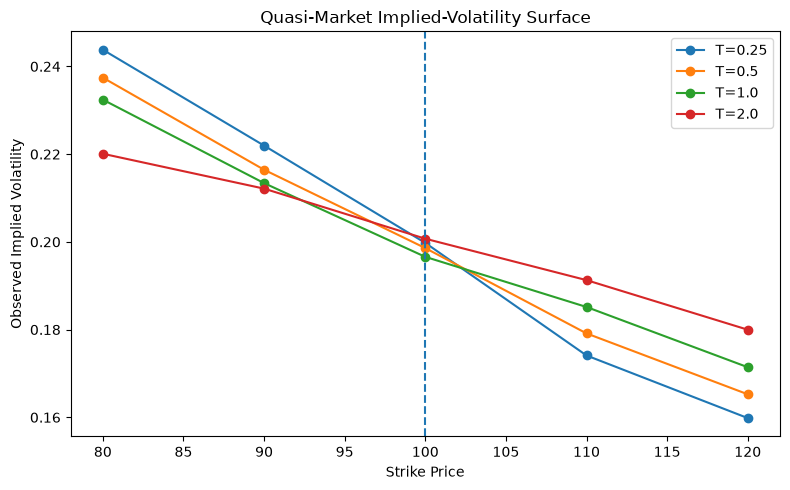

In [5]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

for maturity in maturity_grid:

    subset = market_df[
        market_df[
            "Maturity"
        ]
        == maturity
    ]

    ax.plot(
        subset["Strike"],
        subset["Market IV"],
        marker="o",
        label=f"T={maturity}",
    )

ax.axvline(
    S0,
    linestyle="--",
)

ax.set_xlabel(
    "Strike Price"
)

ax.set_ylabel(
    "Observed Implied Volatility"
)

ax.set_title(
    "Quasi-Market Implied-Volatility Surface"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "model_comparison_market_iv.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 3. Best-Fit Constant-Volatility Black-Scholes Model

The Black-Scholes benchmark is not assigned an arbitrary volatility.

Instead, one constant volatility is estimated from all option prices simultaneously.

This gives Black-Scholes the best possible constant-volatility fit to the quasi-market surface.

In [6]:
bs_start = perf_counter()

bs_result = (
    calibrate_black_scholes_constant_vol(
        market_prices=market_prices,
        S0=S0,
        r=r,
        strikes=strikes,
        maturities=maturities,
    )
)

bs_elapsed = (
    perf_counter()
    - bs_start
)

print(
    "Success:",
    bs_result["success"],
)

print(
    "Best-fit sigma:",
    bs_result["sigma"],
)

print(
    "Price RMSE:",
    bs_result["rmse"],
)

print(
    "Price MAE:",
    bs_result["mae"],
)

print(
    "Elapsed seconds:",
    bs_elapsed,
)

Success: True
Best-fit sigma: 0.19346251086130153
Price RMSE: 0.432046058398518
Price MAE: 0.370759279265651
Elapsed seconds: 0.010407459019916132


## 4. Best-Fit Heston Model

The Heston model is now calibrated to exactly the same quasi-market observations.

The calibration is performed in option-price space using the semi-analytical Fourier pricing engine developed previously.

The initial parameter guess is deliberately different from the parameter vector used to generate the underlying surface.

In [7]:
heston_initial_guess = np.array(
    [
        0.06,
        1.20,
        0.06,
        0.50,
        -0.40,
    ],
    dtype=float,
)

heston_start = perf_counter()

heston_result = (
    calibrate_heston(
        market_prices=market_prices,
        S0=S0,
        r=r,
        strikes=strikes,
        maturities=maturities,
        initial_guess=(
            heston_initial_guess
        ),
        integration_limit=100.0,
        max_nfev=250,
        verbose=0,
    )
)

heston_elapsed = (
    perf_counter()
    - heston_start
)

print(
    "Success:",
    heston_result["success"],
)

print(
    "Price RMSE:",
    heston_result["rmse"],
)

print(
    "Price MAE:",
    heston_result["mae"],
)

print(
    "Elapsed seconds:",
    heston_elapsed,
)

print()

print(
    "Calibrated parameters:"
)

for parameter_name in PARAMETER_NAMES:

    print(
        parameter_name,
        "=",
        heston_result[
            "parameters"
        ][parameter_name],
    )

Success: True
Price RMSE: 0.03842700735071532
Price MAE: 0.03147139506714627
Elapsed seconds: 2.4032187499979045

Calibrated parameters:
v0 = 0.03968491499267474
kappa = 1.498288311709287
theta = 0.040137763971898305
xi = 0.26263011579440637
rho = -0.7276393767101407


In [8]:
model_comparison_df = pd.DataFrame(
    {
        "Model": [
            "Black-Scholes",
            "Heston",
        ],
        "Price RMSE": [
            bs_result["rmse"],
            heston_result["rmse"],
        ],
        "Price MAE": [
            bs_result["mae"],
            heston_result["mae"],
        ],
        "Elapsed Seconds": [
            bs_elapsed,
            heston_elapsed,
        ],
        "Number of Parameters": [
            1,
            5,
        ],
    }
)

model_comparison_df

,Model,Price RMSE,Price MAE,Elapsed Seconds,Number of Parameters
0,Black-Scholes,0.432046,0.370759,0.010407,1
1,Heston,0.038427,0.031471,2.403219,5


In [9]:
rmse_reduction = (
    1.0
    -
    heston_result["rmse"]
    / bs_result["rmse"]
)

mae_reduction = (
    1.0
    -
    heston_result["mae"]
    / bs_result["mae"]
)

print(
    "Relative price RMSE reduction:",
    f"{100 * rmse_reduction:.2f}%",
)

print(
    "Relative price MAE reduction:",
    f"{100 * mae_reduction:.2f}%",
)

Relative price RMSE reduction: 91.11%
Relative price MAE reduction: 91.51%


## 5. Observation-Level Price Comparison

Aggregate error measures such as RMSE summarize overall fitting performance, but they do not reveal whether pricing errors contain systematic structure.

The fitted prices from both models are therefore compared at the individual option level across strikes and maturities.

In [10]:
comparison_df = market_df[
    [
        "Strike",
        "Maturity",
        "Market IV",
        "Market Price",
    ]
].copy()

comparison_df[
    "BS Fitted Price"
] = bs_result[
    "fitted_prices"
]

comparison_df[
    "Heston Fitted Price"
] = heston_result[
    "fitted_prices"
]

comparison_df[
    "BS Price Residual"
] = (
    comparison_df[
        "BS Fitted Price"
    ]
    -
    comparison_df[
        "Market Price"
    ]
)

comparison_df[
    "Heston Price Residual"
] = (
    comparison_df[
        "Heston Fitted Price"
    ]
    -
    comparison_df[
        "Market Price"
    ]
)

comparison_df

,Strike,Maturity,Market IV,Market Price,BS Fitted Price,Heston Fitted Price,BS Price Residual,Heston Price Residual
0,80.0,0.25,0.243804,21.103488,21.014726,21.096348,-0.088763,-0.007141
1,90.0,0.25,0.221947,11.890662,11.610193,11.868522,-0.280469,-0.022141
2,100.0,0.25,0.199766,4.610408,4.486603,4.584812,-0.123804,-0.025596
3,110.0,0.25,0.174104,0.828242,1.095892,0.873178,0.267650,0.044936
4,120.0,0.25,0.159831,0.052470,0.167818,0.053266,0.115349,0.000796
5,80.0,0.50,0.237442,22.431001,22.141453,22.425806,-0.289548,-0.005195
6,90.0,0.50,0.216446,13.791306,13.387416,13.808771,-0.403890,0.017465
7,100.0,0.50,0.198584,6.850004,6.709952,6.840087,-0.140052,-0.009917
8,110.0,0.50,0.179134,2.376553,2.738770,2.389950,0.362217,0.013397
9,120.0,0.50,0.165255,0.520517,0.917625,0.498558,0.397108,-0.021959


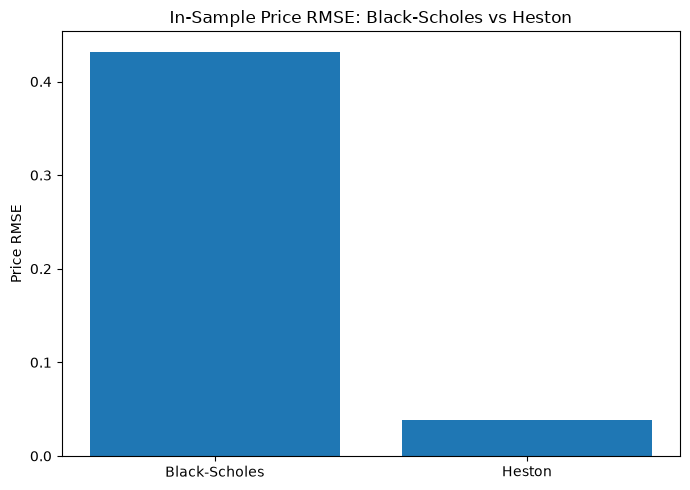

In [11]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.bar(
    model_comparison_df["Model"],
    model_comparison_df[
        "Price RMSE"
    ],
)

ax.set_ylabel(
    "Price RMSE"
)

ax.set_title(
    "In-Sample Price RMSE: Black-Scholes vs Heston"
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "bs_vs_heston_price_rmse.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

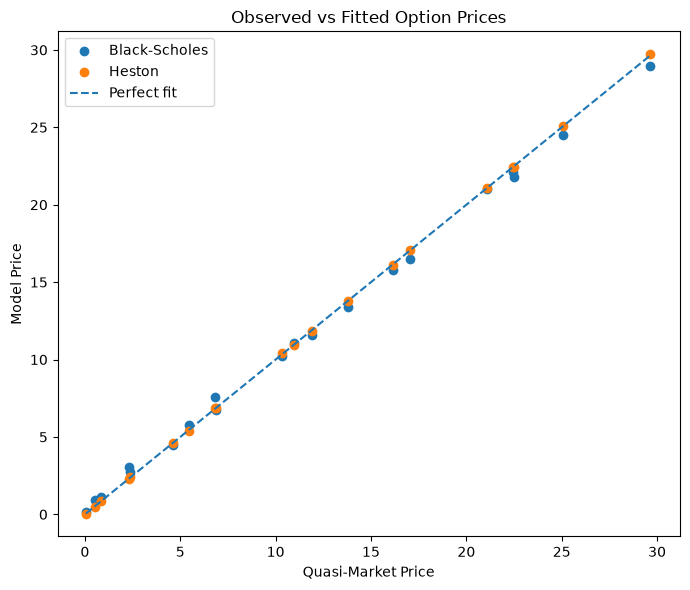

In [12]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.scatter(
    comparison_df[
        "Market Price"
    ],
    comparison_df[
        "BS Fitted Price"
    ],
    label="Black-Scholes",
)

ax.scatter(
    comparison_df[
        "Market Price"
    ],
    comparison_df[
        "Heston Fitted Price"
    ],
    label="Heston",
)

minimum_price = min(
    comparison_df[
        "Market Price"
    ].min(),
    comparison_df[
        "BS Fitted Price"
    ].min(),
    comparison_df[
        "Heston Fitted Price"
    ].min(),
)

maximum_price = max(
    comparison_df[
        "Market Price"
    ].max(),
    comparison_df[
        "BS Fitted Price"
    ].max(),
    comparison_df[
        "Heston Fitted Price"
    ].max(),
)

ax.plot(
    [
        minimum_price,
        maximum_price,
    ],
    [
        minimum_price,
        maximum_price,
    ],
    linestyle="--",
    label="Perfect fit",
)

ax.set_xlabel(
    "Quasi-Market Price"
)

ax.set_ylabel(
    "Model Price"
)

ax.set_title(
    "Observed vs Fitted Option Prices"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "bs_vs_heston_price_fit.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 6. Implied-Volatility Fit Comparison

Price errors alone can be difficult to compare across strikes because option prices differ substantially in magnitude.

The fitted prices are therefore converted into Black-Scholes implied volatilities.

For the constant-volatility Black-Scholes model, the fitted implied volatility is the same for every option:

$$
\sigma_{\mathrm{BS}}(K,T)=\hat{\sigma}.
$$

The calibrated Heston model instead generates strike- and maturity-dependent implied volatilities.

Comparing the fitted implied-volatility structures provides a direct diagnostic of model-specification error.

In [13]:
bs_fitted_ivs = np.full(
    len(comparison_df),
    bs_result["sigma"],
    dtype=float,
)

heston_fitted_ivs = []

for strike, maturity, price in zip(
    comparison_df["Strike"],
    comparison_df["Maturity"],
    comparison_df[
        "Heston Fitted Price"
    ],
):

    iv = implied_volatility(
        market_price=float(price),
        S=S0,
        K=float(strike),
        T=float(maturity),
        r=r,
        option_type="call",
    )

    heston_fitted_ivs.append(
        iv
    )

heston_fitted_ivs = np.asarray(
    heston_fitted_ivs
)

comparison_df[
    "BS Fitted IV"
] = bs_fitted_ivs

comparison_df[
    "Heston Fitted IV"
] = heston_fitted_ivs

In [14]:
bs_iv_residuals = (
    comparison_df[
        "BS Fitted IV"
    ]
    -
    comparison_df[
        "Market IV"
    ]
)

heston_iv_residuals = (
    comparison_df[
        "Heston Fitted IV"
    ]
    -
    comparison_df[
        "Market IV"
    ]
)

comparison_df[
    "BS IV Residual"
] = bs_iv_residuals

comparison_df[
    "Heston IV Residual"
] = heston_iv_residuals


bs_iv_rmse = np.sqrt(
    np.mean(
        bs_iv_residuals**2
    )
)

heston_iv_rmse = np.sqrt(
    np.mean(
        heston_iv_residuals**2
    )
)

bs_iv_mae = np.mean(
    np.abs(
        bs_iv_residuals
    )
)

heston_iv_mae = np.mean(
    np.abs(
        heston_iv_residuals
    )
)

iv_comparison_df = pd.DataFrame(
    {
        "Model": [
            "Black-Scholes",
            "Heston",
        ],
        "IV RMSE": [
            bs_iv_rmse,
            heston_iv_rmse,
        ],
        "IV MAE": [
            bs_iv_mae,
            heston_iv_mae,
        ],
    }
)

iv_comparison_df

,Model,IV RMSE,IV MAE
0,Black-Scholes,0.024655,0.020667
1,Heston,0.001598,0.001355


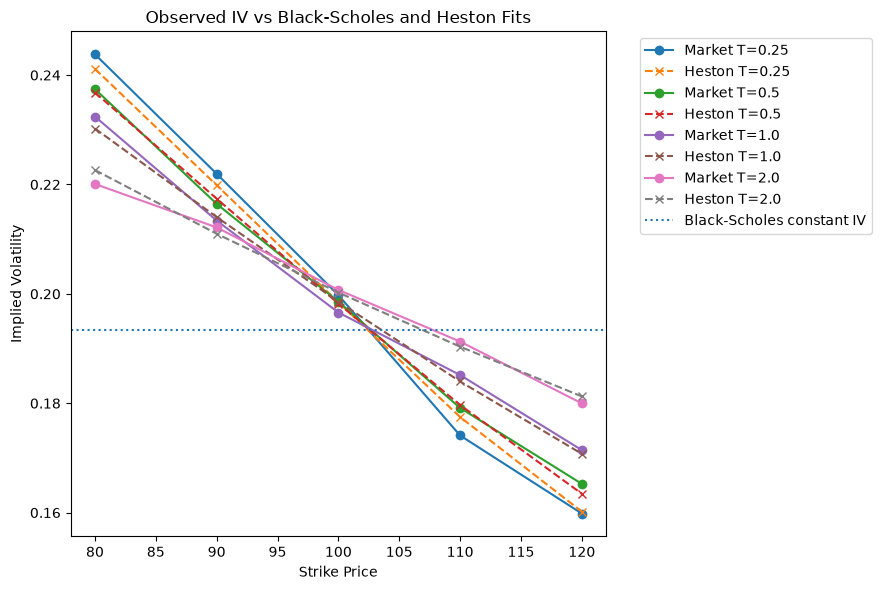

In [15]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

for maturity in maturity_grid:

    subset = comparison_df[
        comparison_df[
            "Maturity"
        ]
        == maturity
    ]

    ax.plot(
        subset["Strike"],
        subset["Market IV"],
        marker="o",
        label=f"Market T={maturity}",
    )

    ax.plot(
        subset["Strike"],
        subset[
            "Heston Fitted IV"
        ],
        linestyle="--",
        marker="x",
        label=f"Heston T={maturity}",
    )

ax.axhline(
    bs_result["sigma"],
    linestyle=":",
    label="Black-Scholes constant IV",
)

ax.set_xlabel(
    "Strike Price"
)

ax.set_ylabel(
    "Implied Volatility"
)

ax.set_title(
    "Observed IV vs Black-Scholes and Heston Fits"
)

ax.legend(
    bbox_to_anchor=(
        1.05,
        1.0,
    ),
    loc="upper left",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "bs_vs_heston_iv_fit.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [16]:
iv_rmse_reduction = (
    1.0
    -
    heston_iv_rmse
    / bs_iv_rmse
)

iv_mae_reduction = (
    1.0
    -
    heston_iv_mae
    / bs_iv_mae
)

print(
    "Relative IV RMSE reduction:",
    f"{100 * iv_rmse_reduction:.2f}%",
)

print(
    "Relative IV MAE reduction:",
    f"{100 * iv_mae_reduction:.2f}%",
)

Relative IV RMSE reduction: 93.52%
Relative IV MAE reduction: 93.44%


## 7. Residual Structure Across Strike and Maturity

A model can have a non-zero RMSE either because of irregular observation noise or because it systematically misses part of the option surface.

To distinguish these cases, pricing residuals are examined jointly across strike and maturity.

A structured residual pattern indicates model-specification error, whereas residuals that remain small and irregular around zero are more consistent with observation noise or residual calibration error.

In [17]:
residual_by_strike = (
    comparison_df
    .groupby("Strike")[
        [
            "BS Price Residual",
            "Heston Price Residual",
        ]
    ]
    .mean()
    .reset_index()
)

residual_by_strike

,Strike,BS Price Residual,Heston Price Residual
0,80.0,-0.413601,0.005111
1,90.0,-0.489756,-0.008150
2,100.0,-0.185704,0.003676
3,110.0,0.269891,-0.010166
4,120.0,0.494844,0.006971


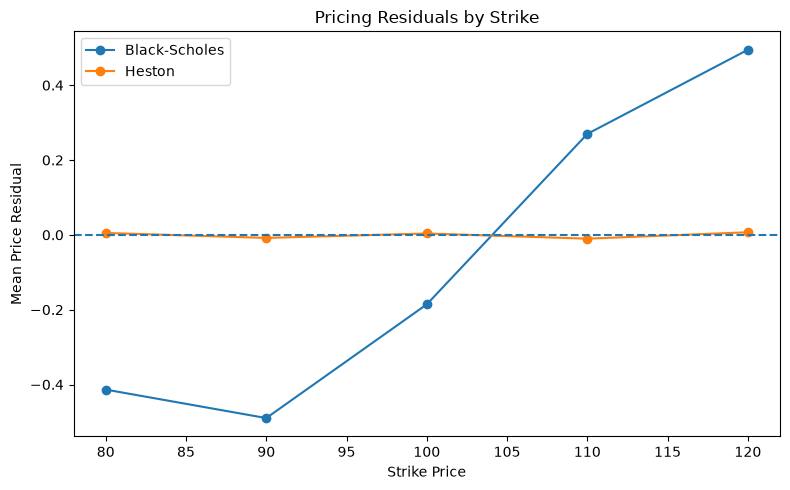

In [18]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    residual_by_strike[
        "Strike"
    ],
    residual_by_strike[
        "BS Price Residual"
    ],
    marker="o",
    label="Black-Scholes",
)

ax.plot(
    residual_by_strike[
        "Strike"
    ],
    residual_by_strike[
        "Heston Price Residual"
    ],
    marker="o",
    label="Heston",
)

ax.axhline(
    0.0,
    linestyle="--",
)

ax.set_xlabel(
    "Strike Price"
)

ax.set_ylabel(
    "Mean Price Residual"
)

ax.set_title(
    "Pricing Residuals by Strike"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "residuals_by_strike.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [19]:
residual_by_maturity = (
    comparison_df
    .groupby("Maturity")[
        [
            "BS Price Residual",
            "Heston Price Residual",
        ]
    ]
    .mean()
    .reset_index()
)

residual_by_maturity

,Maturity,BS Price Residual,Heston Price Residual
0,0.25,-0.022007,-0.001829
1,0.50,-0.014833,-0.001242
2,1.00,-0.041560,-0.002731
3,2.00,-0.181060,0.003755


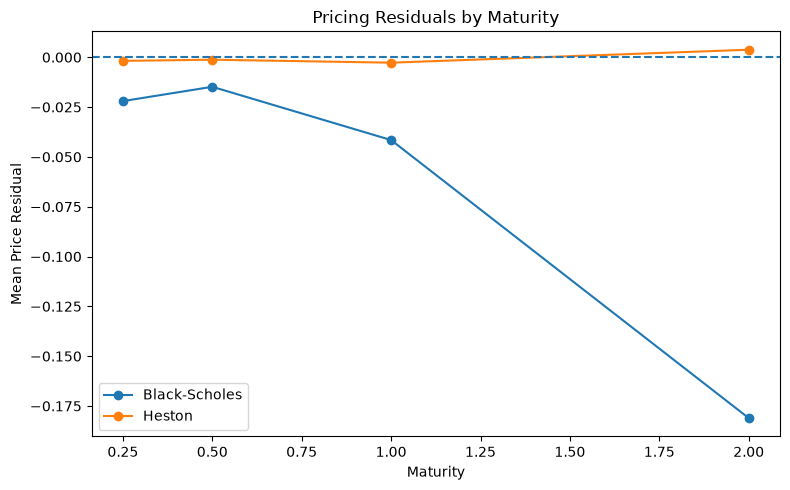

In [20]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    residual_by_maturity["Maturity"],
    residual_by_maturity["BS Price Residual"],
    marker="o",
    label="Black-Scholes",
)

ax.plot(
    residual_by_maturity["Maturity"],
    residual_by_maturity["Heston Price Residual"],
    marker="o",
    label="Heston",
)

ax.axhline(
    0.0,
    linestyle="--",
)

ax.set_xlabel(
    "Maturity"
)

ax.set_ylabel(
    "Mean Price Residual"
)

ax.set_title(
    "Pricing Residuals by Maturity"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "residuals_by_maturity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [21]:
bs_residual_matrix = (
    comparison_df
    .pivot(
        index="Maturity",
        columns="Strike",
        values="BS Price Residual",
    )
)

heston_residual_matrix = (
    comparison_df
    .pivot(
        index="Maturity",
        columns="Strike",
        values="Heston Price Residual",
    )
)

print("Black-Scholes residual matrix:")
display(bs_residual_matrix)

print("Heston residual matrix:")
display(heston_residual_matrix)

Black-Scholes residual matrix:


Strike,80.0,90.0,100.0,110.0,120.0
Maturity,,,,,
0.25,-0.088763,-0.280469,-0.123804,0.267650,0.115349
0.50,-0.289548,-0.403890,-0.140052,0.362217,0.397108
1.00,-0.590372,-0.546555,-0.117157,0.327919,0.718362
2.00,-0.685723,-0.728110,-0.361803,0.121780,0.748556


Heston residual matrix:


Strike,80.0,90.0,100.0,110.0,120.0
Maturity,,,,,
0.25,-0.007141,-0.022141,-0.025596,0.044936,0.000796
0.50,-0.005195,0.017465,-0.009917,0.013397,-0.021959
1.00,-0.037792,0.017935,0.074042,-0.046431,-0.021408
2.00,0.070569,-0.045858,-0.023826,-0.052568,0.070457


In [22]:
residual_limit = max(
    np.max(
        np.abs(
            bs_residual_matrix.values
        )
    ),
    np.max(
        np.abs(
            heston_residual_matrix.values
        )
    ),
)

print(
    "Common residual scale:",
    residual_limit,
)

Common residual scale: 0.7485558130210421


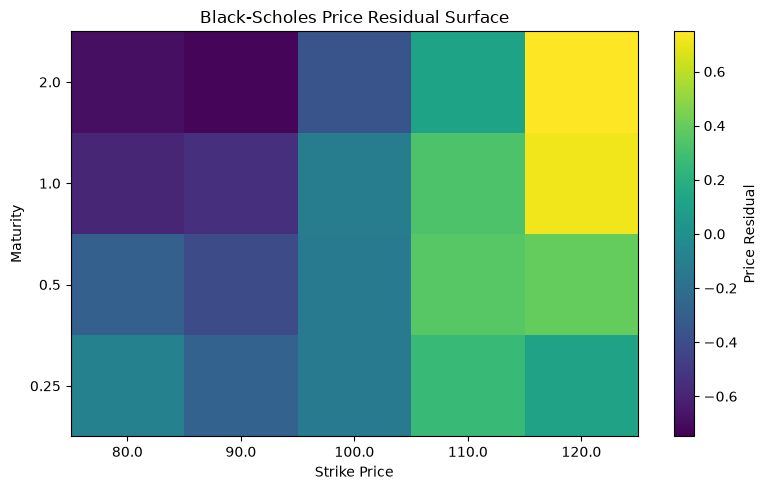

In [23]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

image = ax.imshow(
    bs_residual_matrix.values,
    aspect="auto",
    origin="lower",
    vmin=-residual_limit,
    vmax=residual_limit,
)

ax.set_xticks(
    np.arange(
        len(bs_residual_matrix.columns)
    )
)

ax.set_xticklabels(
    bs_residual_matrix.columns
)

ax.set_yticks(
    np.arange(
        len(bs_residual_matrix.index)
    )
)

ax.set_yticklabels(
    bs_residual_matrix.index
)

ax.set_xlabel("Strike Price")
ax.set_ylabel("Maturity")

ax.set_title(
    "Black-Scholes Price Residual Surface"
)

fig.colorbar(
    image,
    ax=ax,
    label="Price Residual",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "bs_residual_surface.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

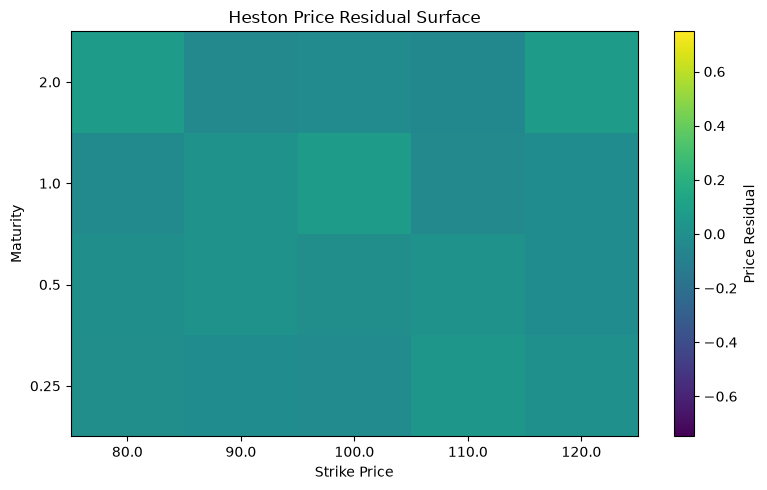

In [24]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

image = ax.imshow(
    heston_residual_matrix.values,
    aspect="auto",
    origin="lower",
    vmin=-residual_limit,
    vmax=residual_limit,
)

ax.set_xticks(
    np.arange(
        len(heston_residual_matrix.columns)
    )
)

ax.set_xticklabels(
    heston_residual_matrix.columns
)

ax.set_yticks(
    np.arange(
        len(heston_residual_matrix.index)
    )
)

ax.set_yticklabels(
    heston_residual_matrix.index
)

ax.set_xlabel("Strike Price")
ax.set_ylabel("Maturity")

ax.set_title(
    "Heston Price Residual Surface"
)

fig.colorbar(
    image,
    ax=ax,
    label="Price Residual",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "heston_residual_surface.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 8. From Numerical Error to Model Error

The earlier stages of the project focused primarily on numerical approximation error.

Monte Carlo pricing introduced sampling uncertainty, while the finite-difference method introduced spatial and temporal discretization error. Heston Monte Carlo simulation additionally involved time-discretization error in the stochastic-variance process, and semi-analytical Heston pricing required numerical Fourier integration.

These errors are fundamentally different from model-specification error.

A useful conceptual decomposition is

$$
\text{Observed Pricing Error}
=
\text{Numerical Error}
+
\text{Calibration Error}
+
\text{Model-Specification Error}
+
\text{Observation Noise}.
$$

In the present experiment, numerical pricing error has already been controlled through analytical benchmarks, convergence checks, characteristic-function identities, Fourier-integration stability, and independent Monte Carlo validation.

The remaining Black-Scholes residuals are therefore particularly informative. They are not distributed randomly around zero. Instead, they show a systematic dependence on strike: the model tends to underprice lower-strike options and overprice higher-strike options under the quasi-market surface examined here.

This structure is consistent with the inability of a single constant-volatility parameter to reproduce the observed volatility skew.

The calibrated Heston model substantially reduces both price-space and implied-volatility errors and leaves much smaller residuals across strikes and maturities.

However, this result should be interpreted carefully. Heston has five calibrated parameters compared with one parameter for the Black-Scholes benchmark, and the comparison is entirely in-sample. The experiment therefore demonstrates greater flexibility and improved structural fit, rather than proving superior out-of-sample predictive performance.

In [25]:
comparison_output_path = (
    DATA_DIR
    / "model_comparison_option_level.csv"
)

summary_output_path = (
    DATA_DIR
    / "model_comparison_summary.csv"
)

comparison_df.to_csv(
    comparison_output_path,
    index=False,
)

final_summary_df = pd.DataFrame(
    {
        "Model": [
            "Black-Scholes",
            "Heston",
        ],
        "Parameters": [
            1,
            5,
        ],
        "Price RMSE": [
            bs_result["rmse"],
            heston_result["rmse"],
        ],
        "Price MAE": [
            bs_result["mae"],
            heston_result["mae"],
        ],
        "IV RMSE": [
            bs_iv_rmse,
            heston_iv_rmse,
        ],
        "IV MAE": [
            bs_iv_mae,
            heston_iv_mae,
        ],
        "Elapsed Seconds": [
            bs_elapsed,
            heston_elapsed,
        ],
    }
)

final_summary_df.to_csv(
    summary_output_path,
    index=False,
)

print(
    "Saved:",
    comparison_output_path,
)

print(
    "Saved:",
    summary_output_path,
)

final_summary_df

Saved: /Users/amber/derivatives-pricing-calibration/data/model_comparison_option_level.csv
Saved: /Users/amber/derivatives-pricing-calibration/data/model_comparison_summary.csv


,Model,Parameters,Price RMSE,Price MAE,IV RMSE,IV MAE,Elapsed Seconds
0,Black-Scholes,1,0.432046,0.370759,0.024655,0.020667,0.010407
1,Heston,5,0.038427,0.031471,0.001598,0.001355,2.403219


## 9. Conclusion

This notebook compared a best-fit constant-volatility Black-Scholes model with a calibrated Heston stochastic-volatility model on the same controlled quasi-market option surface.

The main findings are:

- The best-fit Black-Scholes model achieved a price RMSE of approximately 0.432, whereas the calibrated Heston model reduced the price RMSE to approximately 0.038.
- This corresponds to an in-sample price RMSE reduction of approximately 91%.
- In implied-volatility space, the Black-Scholes RMSE was approximately 0.0247, compared with approximately 0.0016 for Heston, corresponding to an improvement of roughly 94%.
- Black-Scholes residuals exhibit a systematic strike-dependent pattern rather than fluctuating irregularly around zero.
- Heston residuals are substantially smaller and remain much closer to zero across the option surface.
- The improved fit is achieved at the cost of greater model complexity and substantially higher computational time.
- The calibrated Heston parameters do not perfectly recover the original generating parameters after noise is introduced, reinforcing the distinction between pricing fit and parameter identification.

Taken together, the results complete the project's progression from numerical error to model error.

The analytical and numerical experiments in the earlier notebooks established when discrepancies arise from approximation methods. The present comparison shows that even after numerical accuracy has been controlled, a structurally restrictive pricing model can still generate systematic errors.

Under the configurations examined here, stochastic volatility provides a substantially better representation of the non-flat implied-volatility surface than a single constant-volatility Black-Scholes specification.